In [6]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "opencv-python", "numpy", "matplotlib"], check=True)

CompletedProcess(args=['c:\\Users\\alexa\\OneDrive - Stanford\\CS 131\\CS 131 Final Project\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'opencv-python', 'numpy', 'matplotlib'], returncode=0)

# Lens Distortion Correction — Demo

This notebook demonstrates that the fisheye lens distortion has been successfully corrected. It shows:

1. A raw video frame with visible barrel distortion
2. The same frame after undistortion
3. A side-by-side comparison with a line overlaid on the field boundary to confirm straightness

In [11]:
import sys
sys.path.insert(0, "../src")

import cv2
import numpy as np
import matplotlib.pyplot as plt
from lens_distortion import load_params, undistort_image

params = load_params("../data/distortion_params.json")

# Use frame 180 — mid-game, matches the reference used during calibration
cap = cv2.VideoCapture("../film.mp4")
cap.set(cv2.CAP_PROP_POS_FRAMES, 180)
ret, raw_bgr = cap.read()
cap.release()

raw = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
undistorted = cv2.cvtColor(undistort_image(raw_bgr, params), cv2.COLOR_BGR2RGB)

print(f"Model : {params.get('model')}")
print(f"fx    : {params['fx']}  (input fisheye focal length, px)")
print(f"k1    : {params['k1']}  (primary distortion coefficient)")
print(f"out_fx: {params.get('out_fx')}  (output focal length — controls FOV)")
print(f"Frame : {raw.shape[1]}×{raw.shape[0]} px")

Model : fisheye
fx    : 577.73  (input fisheye focal length, px)
k1    : 0.1  (primary distortion coefficient)
out_fx: 385.16  (output focal length — controls FOV)
Frame : 1920×1080 px


## Raw vs. Undistorted

The field boundary line at the bottom curves visibly in the raw frame. After undistortion it is straight.

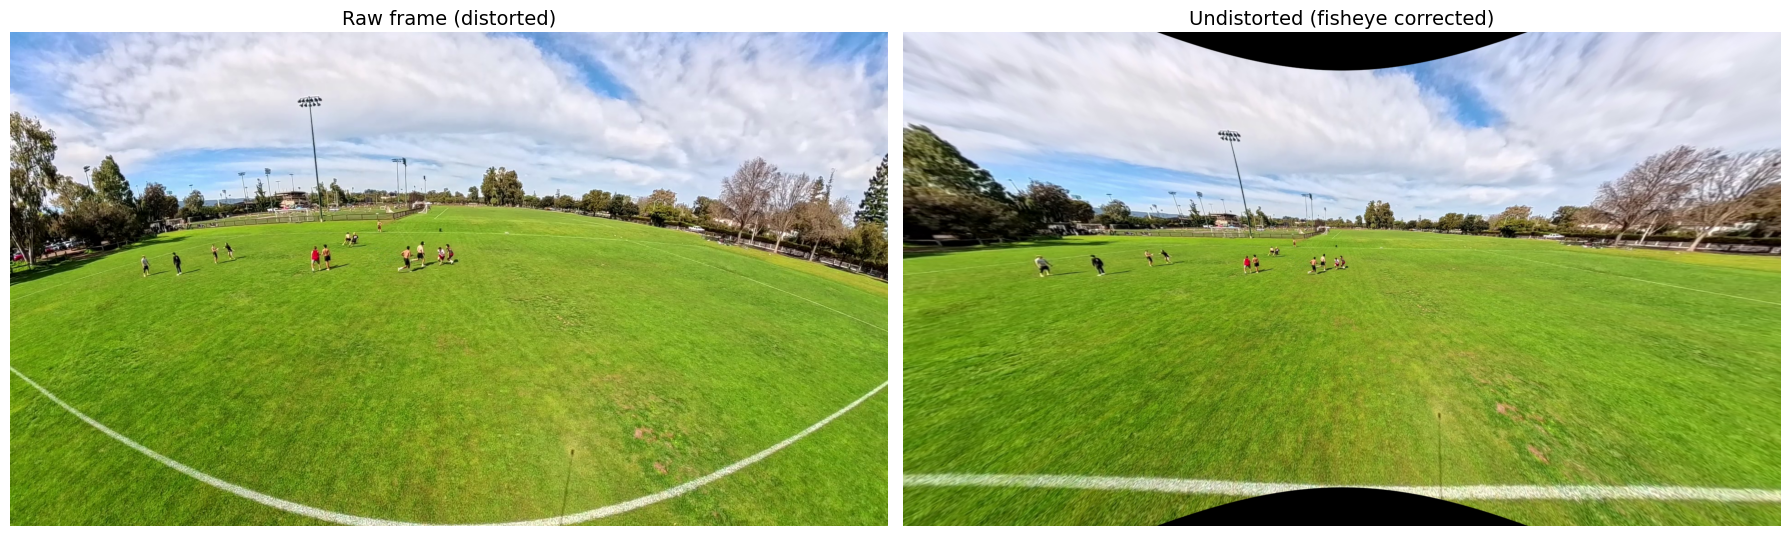

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(raw)
axes[0].set_title("Raw frame (distorted)", fontsize=14)
axes[0].axis("off")

axes[1].imshow(undistorted)
axes[1].set_title("Undistorted (fisheye corrected)", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Straightness Check — Field Boundary Line

We fit a straight line to the white field boundary pixels in the undistorted image and overlay it. If the correction is good, the fitted line should lie exactly on top of the boundary.

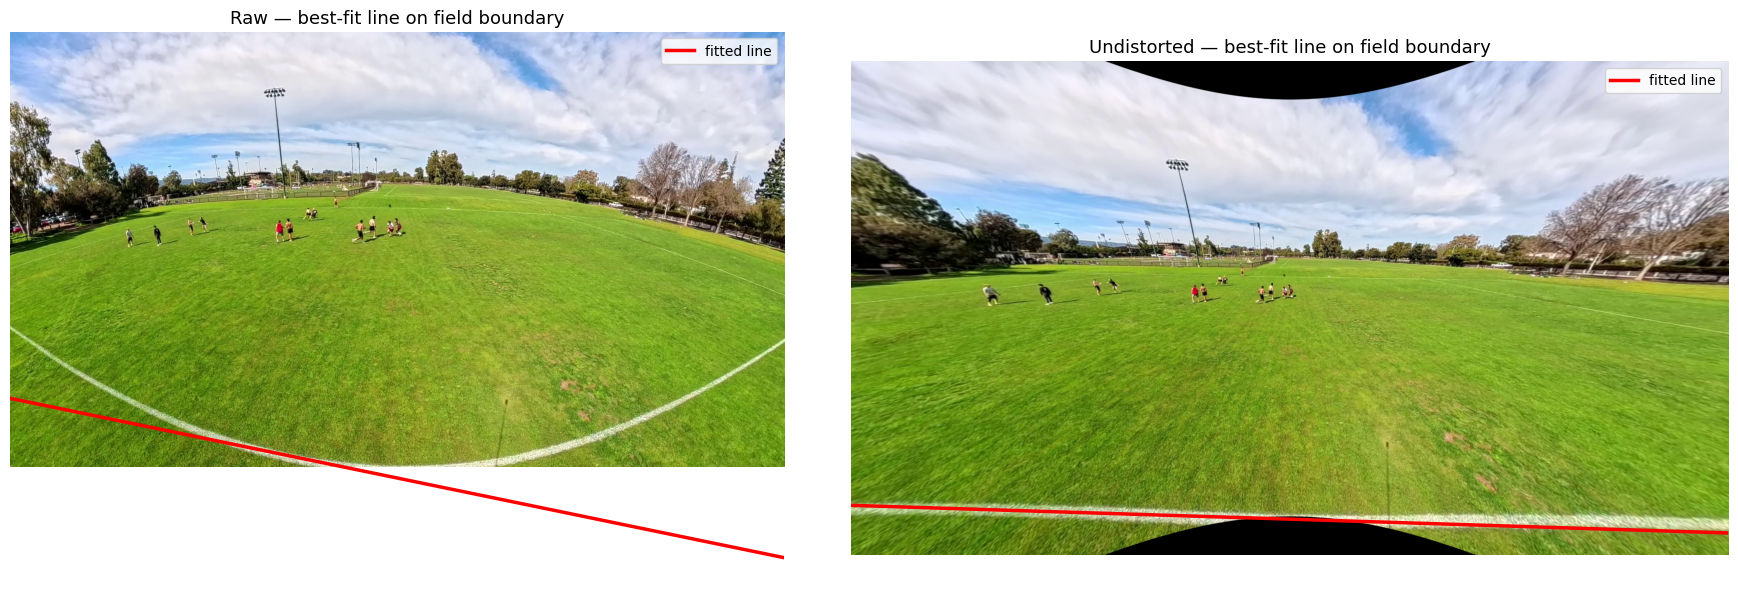

In [14]:
def detect_field_line(image_bgr):
    """
    Detect the white field boundary line in the bottom half of the image.
    Returns (xs, ys) of white pixels and the best-fit line coefficients (a, b)
    for y = a*x + b.
    """
    h, w = image_bgr.shape[:2]
    roi = image_bgr[h // 2:, :]          # look only in the bottom half

    # Threshold for white pixels (high brightness, low saturation)
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, (0, 0, 180), (180, 50, 255))

    # Keep only the largest connected component to exclude noise
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    if n_labels < 2:
        return None, None, None
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    clean = (labels == largest).astype(np.uint8) * 255

    ys, xs = np.where(clean > 0)
    ys = ys + h // 2   # shift back to full-image coordinates

    # Fit a line: y = a*x + b
    if len(xs) < 10:
        return None, None, None
    coeffs = np.polyfit(xs, ys, 1)
    return xs, ys, coeffs


undist_bgr = undistort_image(raw_bgr, params)
raw_disp   = cv2.cvtColor(raw_bgr,   cv2.COLOR_BGR2RGB)
undist_disp = cv2.cvtColor(undist_bgr, cv2.COLOR_BGR2RGB)

xs_raw,   ys_raw,   c_raw   = detect_field_line(raw_bgr)
xs_undist, ys_undist, c_undist = detect_field_line(undist_bgr)

h, w = raw_bgr.shape[:2]
x_span = np.array([0, w - 1])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(raw_disp)
if c_raw is not None:
    axes[0].plot(x_span, np.polyval(c_raw, x_span), "r-", linewidth=2.5, label="fitted line")
axes[0].set_title("Raw — best-fit line on field boundary", fontsize=13)
axes[0].legend(loc="upper right")
axes[0].axis("off")

axes[1].imshow(undist_disp)
if c_undist is not None:
    axes[1].plot(x_span, np.polyval(c_undist, x_span), "r-", linewidth=2.5, label="fitted line")
axes[1].set_title("Undistorted — best-fit line on field boundary", fontsize=13)
axes[1].legend(loc="upper right")
axes[1].axis("off")

plt.tight_layout()
plt.show()